# HCM Causal Estimand Estimation — Demo Notebook

This notebook demonstrates the `estimation.py` module:  
- **Section 1** — `ConditionalDensityEstimator`: all 12 parametric families  
- **Section 2** — `SubunitParamEstimator`: per-unit ATE (paper Appendix D.1)  
- **Section 3** — `ast_to_estimator`: end-to-end causal estimand evaluation  
  - Confounder model (backdoor, per-unit path)  
  - Instrument model (formula-eval path)  
  - Multiple distribution families compared  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from hierarchicalcausalmodels.estimation import (
    ConditionalDensityEstimator,
    SubunitParamEstimator,
    compute_q_from_subunit_data,
    ast_to_estimator,
    SUPPORTED_FAMILIES,
)

rng = np.random.default_rng(42)
print('Available families:', sorted(SUPPORTED_FAMILIES))

Available families: ['bernoulli', 'beta', 'exponential', 'gamma', 'gaussian', 'half_cauchy', 'halfcauchy', 'inverse_gaussian', 'laplace', 'log_normal', 'lognormal', 'nonparametric', 'normal', 'poisson', 'student_t', 't', 'wald', 'weibull']


---
## 1 — ConditionalDensityEstimator: all parametric families

For each family we:
1. Generate synthetic data from the true distribution  
2. Fit the estimator (marginal and conditional)  
3. Plot the fitted density vs the true density  
4. Check that `expectation()` is close to the true mean

In [3]:
# ── synthetic datasets for each family ──────────────────────────────────────
n = 500
X_cond = rng.standard_normal((n, 2))   # 2 conditioning features
# linear effect: true mean = 1 + 0.5*X[:,0] - 0.3*X[:,1]
true_mu = 1.0 + 0.5 * X_cond[:, 0] - 0.3 * X_cond[:, 1]

family_datasets = {
    'bernoulli':        (rng.binomial(1, 1/(1+np.exp(-true_mu*0.5))).astype(float), 'P(Y=1)', (0, 1)),
    'poisson':          (rng.poisson(np.exp(0.5 * true_mu)).astype(float),            'λ',      (0, 15)),
    'gaussian':         (true_mu + rng.normal(0, 0.8, n),                             'μ',      (-3, 5)),
    'laplace':          (true_mu + rng.laplace(0, 0.6, n),                            'loc',    (-3, 5)),
    'student_t':        (true_mu + stats.t.rvs(df=4, size=n, random_state=rng),       'loc',    (-5, 7)),
    'exponential':      (rng.exponential(np.exp(0.3 * true_mu)),                      'λ',      (0, 10)),
    'gamma':            (rng.gamma(2.0, np.exp(0.3 * true_mu) / 2),                  'E[Y]',   (0, 12)),
    'lognormal':        (np.exp(0.4 * true_mu + rng.normal(0, 0.5, n)),               'E[Y]',   (0, 15)),
    'weibull':          (rng.weibull(1.8, n) * np.exp(0.25 * true_mu),               'E[Y]',   (0, 8)),
    'inverse_gaussian': (rng.wald(np.exp(0.3 * true_mu), 1.5, n),                    'μ',      (0, 10)),
    'beta':             (rng.beta(2 + true_mu, 5 - 0.5 * true_mu),                   'E[Y]',   (0, 1)),
    'nonparametric':    (true_mu + rng.normal(0, 0.8, n),                             '—',      (-3, 5)),
}

print('Datasets generated.')

Datasets generated.


In [4]:
# ── fit all families and show a summary table ─────────────────────────────
from IPython.display import display
import pandas as pd

x_query = np.array([0.5, -0.3])   # evaluation point for conditional stats
true_mu_at_xq = 1.0 + 0.5 * 0.5 - 0.3 * (-0.3)   # = 1.34

rows = []
for family, (Y, target, _) in family_datasets.items():
    est = ConditionalDensityEstimator(family).fit(Y, X_cond)
    e_cond = est.expectation(x_query)
    e_marg = est.expectation()
    par = est.params()
    par_str = ', '.join(f'{k}={v:.3f}' for k, v in list(par.items())[:3])
    rows.append({'family': family, 'E[Y|X=xq]': round(e_cond, 4),
                 'E[Y] (marginal)': round(e_marg, 4), 'fitted params (marginal)': par_str})

df = pd.DataFrame(rows).set_index('family')
display(df)

,E[Y|X=xq],E[Y] (marginal),fitted params (marginal)
family,,,
bernoulli,0.6802,0.6420,p=0.642
poisson,2.0299,1.8200,lambda=1.820
gaussian,1.3526,1.0726,"mu=1.073, sigma=0.809"
laplace,1.3255,0.9876,"loc=0.988, scale=0.588"
student_t,1.3375,0.9331,"df=4.768, loc=0.933, scale=0.996"
exponential,1.4857,1.3615,lambda=0.734
gamma,1.5746,1.4318,"shape=1.889, scale=0.758"
lognormal,1.8937,1.6253,"mu_log=0.374, sigma_log=0.473"
weibull,1.2706,1.1812,"shape=1.696, scale=1.323"


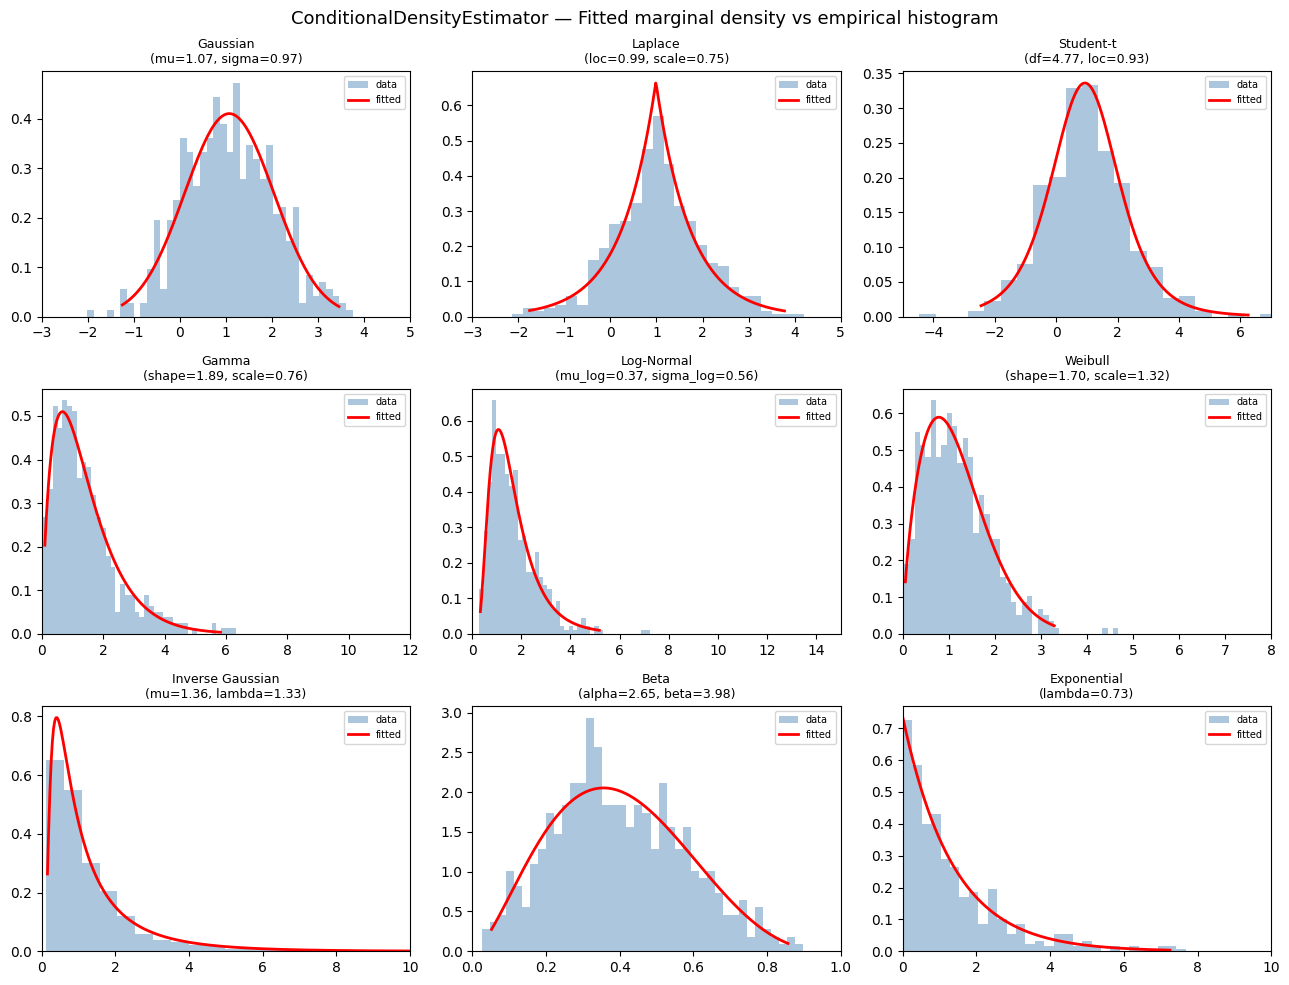

In [5]:
# ── density plots: fitted vs empirical histogram ──────────────────────────
families_to_plot = [
    ('gaussian', 'Gaussian'),
    ('laplace', 'Laplace'),
    ('student_t', 'Student-t'),
    ('gamma', 'Gamma'),
    ('lognormal', 'Log-Normal'),
    ('weibull', 'Weibull'),
    ('inverse_gaussian', 'Inverse Gaussian'),
    ('beta', 'Beta'),
    ('exponential', 'Exponential'),
]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
fig.suptitle('ConditionalDensityEstimator — Fitted marginal density vs empirical histogram', fontsize=13)

for ax, (family, title) in zip(axes.ravel(), families_to_plot):
    Y, _, xlim = family_datasets[family]
    est_marg = ConditionalDensityEstimator(family).fit(Y)  # marginal (no X)
    xgrid = np.linspace(max(xlim[0], float(np.percentile(Y, 0.5))),
                        min(xlim[1], float(np.percentile(Y, 99.5))), 300)
    fitted_pdf = np.array([est_marg.prob(v) for v in xgrid])
    ax.hist(Y, bins=40, density=True, alpha=0.45, color='steelblue', label='data')
    ax.plot(xgrid, fitted_pdf, 'r-', lw=2, label='fitted')
    par = est_marg.params()
    par_str = ', '.join(f'{k}={v:.2f}' for k, v in list(par.items())[:2])
    ax.set_title(f'{title}\n({par_str})', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlim(xlim)

plt.tight_layout()
plt.show()

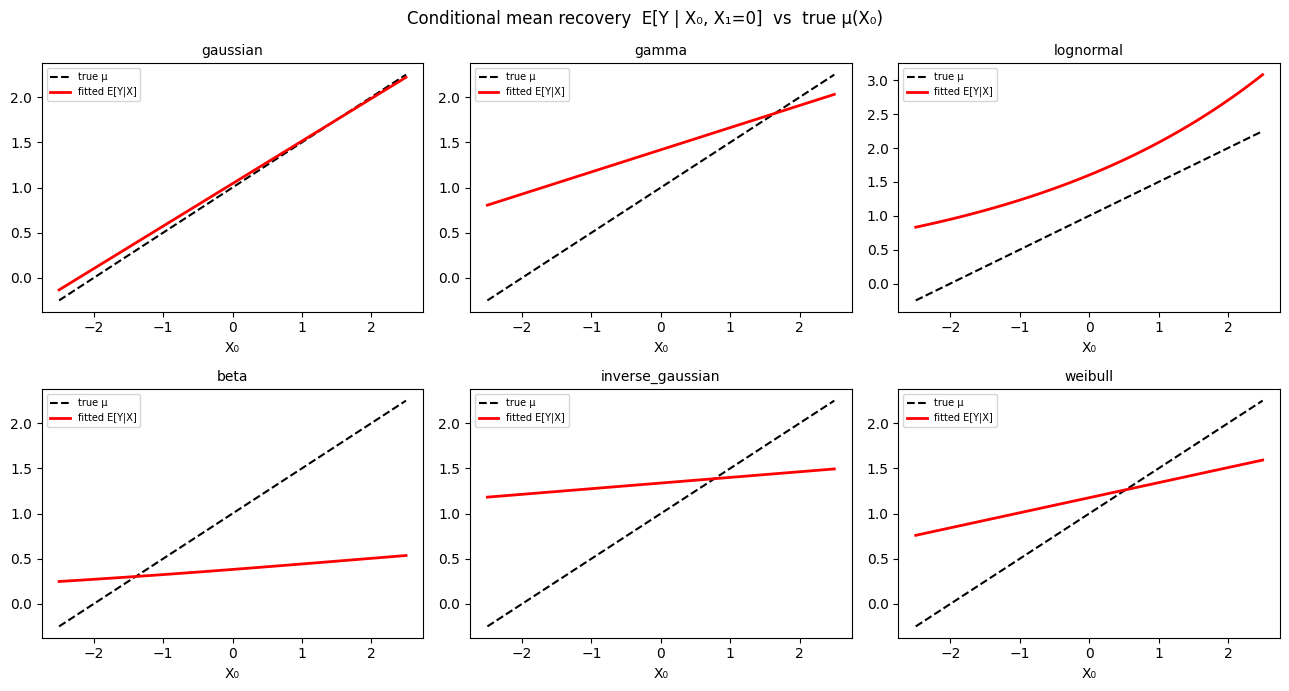

In [6]:
# ── conditional mean recovery ─────────────────────────────────────────────
# Show that fitted E[Y|X=x] tracks the true conditional mean for a sweep of X[:,0]

families_show = ['gaussian', 'gamma', 'lognormal', 'beta', 'inverse_gaussian', 'weibull']
x0_grid = np.linspace(-2.5, 2.5, 60)
X_sweep = np.column_stack([x0_grid, np.zeros_like(x0_grid)])   # X[:,1] = 0
true_mu_sweep = 1.0 + 0.5 * x0_grid   # true conditional mean (X[:,1]=0)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle('Conditional mean recovery  E[Y | X₀, X₁=0]  vs  true μ(X₀)', fontsize=12)

for ax, family in zip(axes.ravel(), families_show):
    Y, _, _ = family_datasets[family]
    est = ConditionalDensityEstimator(family).fit(Y, X_cond)
    pred_mu = np.array([est.expectation(X_sweep[i]) for i in range(len(X_sweep))])
    ax.plot(x0_grid, true_mu_sweep, 'k--', lw=1.5, label='true μ')
    ax.plot(x0_grid, pred_mu, 'r-', lw=2, label='fitted E[Y|X]')
    ax.set_title(family, fontsize=10)
    ax.set_xlabel('X₀'); ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---
## 2 — SubunitParamEstimator: per-unit ATE (paper Appendix D.1)

In the HCM confounder model, the ATE is  
$$\widehat{\mathrm{ATE}} = \frac{1}{n}\sum_{i=1}^n \hat{\mu}^y_i(a^*)$$  
where $\hat{\mu}^y_i(a^*)$ is the per-unit conditional expectation fitted from within-unit subunit data.

In [7]:
# ── synthetic HCM data: units with different treatment propensities ───────
n_units  = 50
n_sub    = 30   # subunits per unit

# Unit-level heterogeneity: each unit has a random background effect U_i
U = rng.normal(0, 1, n_units)
# Treatment: A_ij | U_i ~ Bernoulli(sigmoid(0.5 * U_i))
p_treat = 1 / (1 + np.exp(-0.5 * U[:, None] * np.ones((n_units, n_sub))))
A = rng.binomial(1, p_treat).astype(float)
# Outcome: Y_ij | A_ij, U_i ~ Bernoulli(sigmoid(1.5*A_ij + U_i))
p_out = 1 / (1 + np.exp(-(1.5 * A + U[:, None])))
Y = rng.binomial(1, p_out).astype(float)

# True ATE: E[Y(1)] - E[Y(0)], estimated via large-sample Monte Carlo
U_mc = rng.normal(0, 1, 10_000)
ey1 = np.mean(1 / (1 + np.exp(-(1.5 + U_mc))))
ey0 = np.mean(1 / (1 + np.exp(-U_mc)))
true_ate = ey1 - ey0
print(f'True ATE (MC): {true_ate:.4f}')

True ATE (MC): 0.2780


In [8]:
# ── fit SubunitParamEstimator with different families ─────────────────────────
results = {}
for family in ['bernoulli', 'gaussian', 'nonparametric']:
    est = SubunitParamEstimator(family).fit(Y, A)
    ate1 = est.ate(1.0)
    ate0 = est.ate(0.0)
    effect = ate1 - ate0
    results[family] = {'ATE(A=1)': ate1, 'ATE(A=0)': ate0, 'effect': effect}
    print(f'{family:<16}  ATE(1)={ate1:.4f}  ATE(0)={ate0:.4f}  effect={effect:.4f}')

print(f'{'true':<16}  —         —         effect={true_ate:.4f}')

bernoulli         ATE(1)=0.7634  ATE(0)=0.4722  effect=0.2912
gaussian          ATE(1)=0.7634  ATE(0)=0.4721  effect=0.2913
nonparametric     ATE(1)=0.7920  ATE(0)=0.4840  effect=0.3080
true              —         —         effect=0.2780


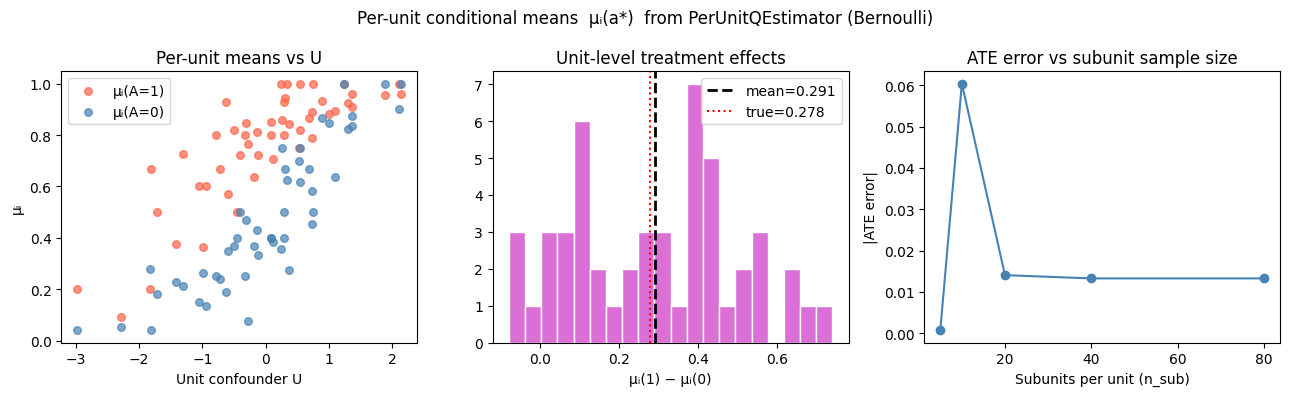

In [9]:
# ── per-unit μ_i(a*) distribution ────────────────────────────────────────
est_bern = SubunitParamEstimator('bernoulli').fit(Y, A)
mu1 = est_bern.per_unit_means(1.0)
mu0 = est_bern.per_unit_means(0.0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Per-unit conditional means  μᵢ(a*)  from SubunitParamEstimator (Bernoulli)', fontsize=12)

axes[0].scatter(U, mu1, alpha=0.7, s=30, color='tomato', label='μᵢ(A=1)')
axes[0].scatter(U, mu0, alpha=0.7, s=30, color='steelblue', label='μᵢ(A=0)')
axes[0].set_xlabel('Unit confounder U'); axes[0].set_ylabel('μᵢ')
axes[0].set_title('Per-unit means vs U'); axes[0].legend()

axes[1].hist(mu1 - mu0, bins=20, color='orchid', edgecolor='white')
axes[1].axvline(np.mean(mu1 - mu0), color='k', lw=2, linestyle='--', label=f'mean={np.mean(mu1-mu0):.3f}')
axes[1].axvline(true_ate, color='red', lw=1.5, linestyle=':', label=f'true={true_ate:.3f}')
axes[1].set_xlabel('μᵢ(1) − μᵢ(0)'); axes[1].set_title('Unit-level treatment effects'); axes[1].legend()

# Error vs n_subunits
n_sub_vals = [5, 10, 20, 40, 80]
errors = []
for ns in n_sub_vals:
    A_s = A[:, :ns]; Y_s = Y[:, :ns]
    e = SubunitParamEstimator('bernoulli').fit(Y_s, A_s)
    errors.append(abs(e.ate(1.0) - e.ate(0.0) - true_ate))
axes[2].plot(n_sub_vals, errors, 'o-', color='steelblue')
axes[2].set_xlabel('Subunits per unit (n_sub)'); axes[2].set_ylabel('|ATE error|')
axes[2].set_title('ATE error vs subunit sample size')

plt.tight_layout()
plt.show()

---
## 3 — ast_to_estimator: end-to-end causal estimand evaluation

We simulate the pyAgrum AST with a `MockAST` whose `.toLatex()` produces the
backdoor identification formula for each model, then evaluate it with `ast_to_estimator`.

In [10]:
# ── Confounder model: P(Q^y | do(Q^a)) via backdoor ──────────────────────
# Identification formula: Σ_U P(Q^y | Q^a, U) * P(U)

class BackdoorAST:
    """Mock AST representing Σ_U P(Q^y | Q^a, U) * P(U) — confounder backdoor."""
    def toLatex(self):
        return r'\sum_{U} P(Qy|Qa,U) \cdot P(U)'

print('Using backdoor formula:', BackdoorAST().toLatex())
print()

Using backdoor formula: \sum_{U} P(Qy|Qa,U) \cdot P(U)



In [11]:
# ── Case 3a: binary Y (confounder, Appendix D.1) ─────────────────────────
# Data: 40 units × 20 subunits, binary A (iid) and Y with unit-level confounder U
# iid A ensures sufficient within-unit variation for per-unit regression

n_u, n_s = 40, 20
U_conf = rng.normal(0, 1, n_u)
A_conf = rng.binomial(1, 0.5, (n_u, n_s)).astype(float)   # iid treatment
p_y = 1 / (1 + np.exp(-(2.0 * A_conf + U_conf[:, None])))
Y_conf = rng.binomial(1, p_y).astype(float)

# True ATE via large-sample MC (marginalises over U)
U_mc2 = rng.normal(0, 1, 50_000)
true_ate_conf = np.mean(1/(1+np.exp(-(2.0+U_mc2)))) - np.mean(1/(1+np.exp(-U_mc2)))
print(f'True ATE (confounder): {true_ate_conf:.4f}')
print()

print(f'{"Method":<30} {"ATE(0)":>8} {"ATE(1)":>8} {"Effect":>8}')
print('-' * 60)
for family in ['bernoulli', 'gaussian', 'nonparametric']:
    ate0 = ast_to_estimator(BackdoorAST(), {'A': A_conf, 'Y': Y_conf}, 0.0,
                            {'Y': family}, per_unit=True)
    ate1 = ast_to_estimator(BackdoorAST(), {'A': A_conf, 'Y': Y_conf}, 1.0,
                            {'Y': family}, per_unit=True)
    print(f'per_unit ({family:<14})  {ate0:>8.4f} {ate1:>8.4f} {ate1-ate0:>8.4f}')

print(f'{"true":<30} {"—":>8} {"—":>8} {true_ate_conf:>8.4f}')

True ATE (confounder): 0.3453

Method                           ATE(0)   ATE(1)   Effect
------------------------------------------------------------
per_unit (bernoulli     )    0.4917   0.8175   0.3258
per_unit (gaussian      )    0.4916   0.8175   0.3259
per_unit (nonparametric )    0.5000   0.8050   0.3050
true                                  —        —   0.3453


In [12]:
# ── Case 3b: continuous Y with different distribution families ───────────
# Data: Y ~ Gamma(2, scale=exp(A+0.3*U)), E[Y|A,U] = 2*exp(A+0.3*U)
# Use iid A to ensure within-unit variation for per-unit regression

n_u2, n_s2 = 40, 25
U2 = rng.normal(0, 0.5, n_u2)
A2 = rng.binomial(1, 0.5, (n_u2, n_s2)).astype(float)   # iid treatment
scale = np.exp(A2 + 0.3 * U2[:, None])
Y2 = rng.gamma(2.0, scale)   # E[Y|A,U] = 2*scale

U_mc3 = rng.normal(0, 0.5, 50_000)
true_ey1 = 2.0 * np.mean(np.exp(1.0 + 0.3 * U_mc3))
true_ey0 = 2.0 * np.mean(np.exp(0.0 + 0.3 * U_mc3))
true_ate2 = true_ey1 - true_ey0
print(f'True ATE (Gamma Y): {true_ate2:.4f}')
print()

print(f'{"Family (Y distribution)":<28} {"ATE(0)":>8} {"ATE(1)":>8} {"Effect":>8} {"Error":>8}')
print('-' * 65)
for family in ['gaussian', 'gamma', 'lognormal', 'exponential', 'nonparametric']:
    try:
        ate0 = ast_to_estimator(BackdoorAST(), {'A': A2, 'Y': Y2}, 0.0,
                                {'Y': family}, per_unit=True)
        ate1 = ast_to_estimator(BackdoorAST(), {'A': A2, 'Y': Y2}, 1.0,
                                {'Y': family}, per_unit=True)
        effect = ate1 - ate0
        err = abs(effect - true_ate2)
        print(f'{family:<28} {ate0:>8.4f} {ate1:>8.4f} {effect:>8.4f} {err:>8.4f}')
    except Exception as e:
        print(f'{family:<28} ERROR: {e}')

print(f'{"true":<28} {true_ey0:>8.4f} {true_ey1:>8.4f} {true_ate2:>8.4f} {"—":>8}')

True ATE (Gamma Y): 3.4738

Family (Y distribution)        ATE(0)   ATE(1)   Effect    Error
-----------------------------------------------------------------
gaussian                       1.9974   5.4766   3.4793   0.0055
gamma                          1.9974   5.4766   3.4793   0.0055
lognormal                      2.1085   5.7061   3.5976   0.1238
exponential                    1.9974   5.4766   3.4793   0.0055
nonparametric                  1.9055   5.6379   3.7324   0.2586
true                           2.0217   5.4955   3.4738        —


In [13]:
# ── Case 3c: bounded outcome Y ∈ (0,1) with Beta family ──────────────────
# Y ~ Beta(2+A, 5-A), E[Y|A] = (2+A)/(7)  →  ATE = 1/7 ≈ 0.143

n_u3, n_s3 = 40, 20
A3 = rng.binomial(1, 0.5, (n_u3, n_s3)).astype(float)
Y3 = rng.beta(2 + A3, 5 - A3)
true_ate3 = np.mean(rng.beta(3, 4, 100_000)) - np.mean(rng.beta(2, 5, 100_000))
print(f'True ATE (Beta Y): {true_ate3:.4f}')
print()

print(f'{'Family':<28} {'ATE(0)':>8} {'ATE(1)':>8} {'Effect':>8}')
print('-' * 55)
for family in ['beta', 'gaussian', 'nonparametric']:
    ate0 = ast_to_estimator(BackdoorAST(), {'A': A3, 'Y': Y3}, 0.0,
                            {'Y': family}, per_unit=True)
    ate1 = ast_to_estimator(BackdoorAST(), {'A': A3, 'Y': Y3}, 1.0,
                            {'Y': family}, per_unit=True)
    print(f'{family:<28} {ate0:>8.4f} {ate1:>8.4f} {ate1-ate0:>8.4f}')
print(f'{'true':<28} {'—':>8} {'—':>8} {true_ate3:>8.4f}')

True ATE (Beta Y): 0.1435

Family                         ATE(0)   ATE(1)   Effect
-------------------------------------------------------
beta                           0.2512   0.4221   0.1709
gaussian                       0.2816   0.4309   0.1493
nonparametric                  0.2677   0.4254   0.1577
true                                —        —   0.1435


In [14]:
# ── Case 3d: Poisson count outcome (interference-style) ──────────────────
# Y ~ Poisson(exp(0.8*A + 0.2*U))  — unit count outcome
# Use iid A to ensure within-unit variation for per-unit regression

n_u4, n_s4 = 50, 25
U4 = rng.normal(0, 0.5, n_u4)
A4 = rng.binomial(1, 0.5, (n_u4, n_s4)).astype(float)   # iid treatment
lam4 = np.exp(0.8 * A4 + 0.2 * U4[:, None])
Y4 = rng.poisson(lam4).astype(float)

U_mc4 = rng.normal(0, 0.5, 50_000)
true_ey1_p = np.mean(np.exp(0.8 + 0.2 * U_mc4))
true_ey0_p = np.mean(np.exp(0.0 + 0.2 * U_mc4))
true_ate4 = true_ey1_p - true_ey0_p
print(f'True ATE (Poisson Y): {true_ate4:.4f}')
print()

print(f'{"Family":<28} {"ATE(0)":>8} {"ATE(1)":>8} {"Effect":>8}')
print('-' * 55)
for family in ['poisson', 'gaussian', 'gamma', 'nonparametric']:
    try:
        ate0 = ast_to_estimator(BackdoorAST(), {'A': A4, 'Y': Y4}, 0.0,
                                {'Y': family}, per_unit=True)
        ate1 = ast_to_estimator(BackdoorAST(), {'A': A4, 'Y': Y4}, 1.0,
                                {'Y': family}, per_unit=True)
        print(f'{family:<28} {ate0:>8.4f} {ate1:>8.4f} {ate1-ate0:>8.4f}')
    except Exception as e:
        print(f'{family:<28} ERROR: {e}')
print(f'{"true":<28} {true_ey0_p:>8.4f} {true_ey1_p:>8.4f} {true_ate4:>8.4f}')

True ATE (Poisson Y): 1.2326

Family                         ATE(0)   ATE(1)   Effect
-------------------------------------------------------
poisson                        1.0195   2.2338   1.2144
gaussian                       1.0195   2.2338   1.2144
gamma                          1.0195   2.2338   1.2144
nonparametric                  1.0280   2.2760   1.2480
true                           1.0057   2.2383   1.2326


In [15]:
# ── Case 3e: formula-eval path (unit-level Q summaries) ──────────────────
# Use heterogeneous per-unit treatment rates so Q^a spans [0.05, 0.95],
# avoiding out-of-distribution extrapolation when evaluating at Q^a=0 and 1.
# n_s=100 makes Q^a_i ≈ p_i (law of large numbers), n_u=80 for stable regression.

n_u5, n_s5 = 80, 100
rng5 = np.random.default_rng(7)
U5 = rng5.normal(0, 1, n_u5)
p_treat5 = rng5.uniform(0.05, 0.95, n_u5)          # heterogeneous treatment rates
A5 = rng5.binomial(1, p_treat5[:, None], (n_u5, n_s5)).astype(float)
p_y5 = 1 / (1 + np.exp(-(2.0 * A5 + U5[:, None])))
Y5 = rng5.binomial(1, p_y5).astype(float)

Qqa5 = A5.mean(axis=1)    # ≈ p_treat5, spans [0.05, 0.95]
Qqy5 = Y5.mean(axis=1)

print(f'Q^a range: {Qqa5.min():.3f} – {Qqa5.max():.3f}  (interventions at 0 & 1 = slight extrapolation)')
print()

# True ATE: E[Q^y|do(Q^a=1)] - E[Q^y|do(Q^a=0)] = E[Y|do(A=1)] - E[Y|do(A=0)]
U_mc5 = rng5.normal(0, 1, 100_000)
true_ey1_f = np.mean(1 / (1 + np.exp(-(2.0 + U_mc5))))
true_ey0_f = np.mean(1 / (1 + np.exp(-U_mc5)))
true_ate_f = true_ey1_f - true_ey0_f
print(f'True E[Q^y|do(Q^a=1)] = {true_ey1_f:.4f}')
print(f'True E[Q^y|do(Q^a=0)] = {true_ey0_f:.4f}')
print(f'True ATE = {true_ate_f:.4f}')
print()

class BackdoorAST5:
    def toLatex(self): return r'\sum_{U} P(Qy|Qa,U) \cdot P(U)'

print(f'{"Family":<16} {"ATE(0)":>8} {"ATE(1)":>8} {"Effect":>8} {"Error":>8}')
print('-' * 55)
for family in ['gaussian', 'bernoulli', 'laplace']:
    ate0 = ast_to_estimator(
        BackdoorAST5(),
        data={'Q^a': Qqa5, 'Q^y': Qqy5, 'U': U5},
        intervention_value={'Q^a': 0.0},
        distribution_families={'Q^y': family},
        per_unit=False, n_mc_samples=500, random_seed=0,
    )
    ate1 = ast_to_estimator(
        BackdoorAST5(),
        data={'Q^a': Qqa5, 'Q^y': Qqy5, 'U': U5},
        intervention_value={'Q^a': 1.0},
        distribution_families={'Q^y': family},
        per_unit=False, n_mc_samples=500, random_seed=0,
    )
    print(f'{family:<16} {ate0:>8.4f} {ate1:>8.4f} {ate1-ate0:>8.4f} {abs(ate1-ate0-true_ate_f):>8.4f}')
print(f'{"true":<16} {true_ey0_f:>8.4f} {true_ey1_f:>8.4f} {true_ate_f:>8.4f} {"—":>8}')

Q^a range: 0.030 – 0.950  (interventions at 0 & 1 = slight extrapolation)

True E[Q^y|do(Q^a=1)] = 0.8445
True E[Q^y|do(Q^a=0)] = 0.4998
True ATE = 0.3447

Family             ATE(0)   ATE(1)   Effect    Error
-------------------------------------------------------
gaussian           0.4719   0.8255   0.3535   0.0089
bernoulli          0.4719   0.8169   0.3449   0.0002
laplace            0.4732   0.8363   0.3631   0.0185
true               0.4998   0.8445   0.3447        —


---
## 4 — Summary figure: ATE recovery across families and sample sizes

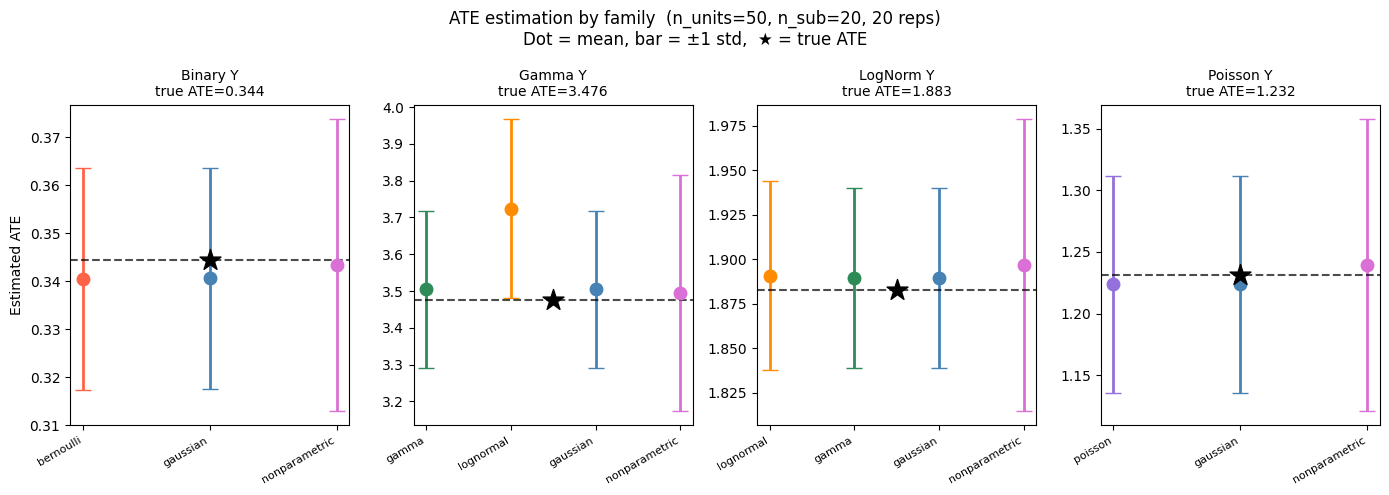

In [33]:
# ── ATE estimation intervals: per-DGP comparison of distribution families ─
# 4 DGPs × compatible families. For each (DGP, family): mean ± std of
# estimated ATE over 20 reps.  True ATE shown as ★.

n_u6, n_s6, n_reps6 = 50, 20, 20

U_mc6  = np.random.default_rng(0).normal(0, 0.5, 200_000)
U_mc6b = np.random.default_rng(0).normal(0, 1,   200_000)
true_ates = {
    'Binary Y':   np.mean(1/(1+np.exp(-(2+U_mc6b)))) - np.mean(1/(1+np.exp(-U_mc6b))),
    'Gamma Y':    2*np.mean(np.exp(1+0.3*U_mc6)) - 2*np.mean(np.exp(0.3*U_mc6)),
    'LogNorm Y':  np.mean(np.exp(1+0.3*U_mc6+0.08)) - np.mean(np.exp(0.3*U_mc6+0.08)),
    'Poisson Y':  np.mean(np.exp(0.8+0.2*U_mc6)) - np.mean(np.exp(0.2*U_mc6)),
}
dgp_families = {
    'Binary Y':   ['bernoulli', 'gaussian',  'nonparametric'],
    'Gamma Y':    ['gamma',     'lognormal', 'gaussian', 'nonparametric'],
    'LogNorm Y':  ['lognormal', 'gamma',     'gaussian', 'nonparametric'],
    'Poisson Y':  ['poisson',   'gaussian',  'nonparametric'],
}

estimates = {d: {f: [] for f in dgp_families[d]} for d in true_ates}

for rep in range(n_reps6):
    rr = np.random.default_rng(rep + 500)
    def gen(n_u, n_s, U_sd):
        U = rr.normal(0, U_sd, n_u)
        A = rr.binomial(1, 0.5, (n_u, n_s)).astype(float)
        return U, A
    U_b, A_b  = gen(n_u6, n_s6, 1.0)
    U_g, A_g  = gen(n_u6, n_s6, 0.5)
    U_ln,A_ln = gen(n_u6, n_s6, 0.5)
    U_p, A_p  = gen(n_u6, n_s6, 0.5)
    Y_bin = rr.binomial(1, 1/(1+np.exp(-(2*A_b  + U_b[:,None])))).astype(float)
    Y_gam = rr.gamma(2.0, np.exp(A_g  + 0.3*U_g[:,None]))
    Y_ln  = np.exp(A_ln + 0.3*U_ln[:,None] + rr.normal(0, 0.4, (n_u6,n_s6)))
    Y_poi = rr.poisson(np.exp(0.8*A_p + 0.2*U_p[:,None])).astype(float)
    datasets = {'Binary Y': (A_b,Y_bin), 'Gamma Y': (A_g,Y_gam),
                'LogNorm Y': (A_ln,Y_ln), 'Poisson Y': (A_p,Y_poi)}
    for dgp, (Ad, Yd) in datasets.items():
        for f in dgp_families[dgp]:
            try:
                a0 = ast_to_estimator(BackdoorAST(), {'A':Ad,'Y':Yd}, 0.0, {'Y':f}, per_unit=True)
                a1 = ast_to_estimator(BackdoorAST(), {'A':Ad,'Y':Yd}, 1.0, {'Y':f}, per_unit=True)
                v = a1 - a0
                if np.isfinite(v):
                    estimates[dgp][f].append(v)
            except Exception:
                pass

# ── plot: 4 subplots, one per DGP ─────────────────────────────────────────
fam_colors = {
    'bernoulli': 'tomato',  'gaussian': 'steelblue', 'gamma': 'seagreen',
    'lognormal': 'darkorange', 'nonparametric': 'orchid', 'poisson': 'mediumpurple',
}

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
fig.suptitle(f'ATE estimation by family  (n_units={n_u6}, n_sub={n_s6}, {n_reps6} reps)\n'
             f'Dot = mean, bar = ±1 std,  ★ = true ATE', fontsize=12)

for ax, (dgp, true_v) in zip(axes, true_ates.items()):
    fams = dgp_families[dgp]
    xs = np.arange(len(fams))
    for xi, f in enumerate(fams):
        vals = estimates[dgp][f]
        if not vals:
            continue
        mu, sd = np.mean(vals), np.std(vals)
        col = fam_colors.get(f, 'gray')
        ax.errorbar(xi, mu, yerr=sd, fmt='o', color=col, capsize=6,
                    markersize=9, lw=2, label=f)
    ax.axhline(true_v, color='black', lw=1.5, ls='--', alpha=0.7)
    ax.scatter(len(fams)/2 - 0.5, true_v, marker='*', s=250, color='black', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels(fams, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{dgp}\ntrue ATE={true_v:.3f}', fontsize=10)
    ax.set_ylabel('Estimated ATE' if ax == axes[0] else '')

plt.tight_layout()
plt.show()

---
## 5 — Family parameter inspection and distribution families aliases

In [34]:
# ── Show params() output for each marginal fit ───────────────────────────
import pandas as pd

param_rows = []
for family, (Y, _, _) in family_datasets.items():
    est = ConditionalDensityEstimator(family).fit(Y)   # marginal
    par = est.params()
    param_rows.append({'family': family, **{k: round(v, 4) for k, v in par.items()}})

df_params = pd.DataFrame(param_rows).set_index('family').fillna('—')
display(df_params)

,p,lambda,mu,sigma,loc,scale,df,shape,mu_log,sigma_log,alpha,beta
family,,,,,,,,,,,,
bernoulli,0.622,—,—,—,—,—,—,—,—,—,—,—
poisson,—,1.69,—,—,—,—,—,—,—,—,—,—
gaussian,—,—,1.05,0.9416,—,—,—,—,—,—,—,—
laplace,—,—,—,—,1.0033,0.7657,—,—,—,—,—,—
student_t,—,—,—,—,0.9574,1.1951,6.3047,—,—,—,—,—
exponential,—,0.7321,—,—,—,—,—,—,—,—,—,—
gamma,—,—,—,—,—,0.7678,—,1.9443,—,—,—,—
lognormal,—,—,—,—,—,—,—,—,0.4146,0.5407,—,—
weibull,—,—,—,—,—,1.2953,—,1.7236,—,—,—,—


In [35]:
# ── Aliases: 'normal', 't', 'log_normal', 'wald' should work ─────────────
Y_test = rng.standard_normal(100)
for alias, canonical in [('normal', 'gaussian'), ('t', 'student_t'),
                          ('log_normal', 'lognormal'), ('wald', 'inverse_gaussian')]:
    est = ConditionalDensityEstimator(alias).fit(np.abs(Y_test) + 0.1)
    print(f'alias {alias!r:15} → family stored as {est.family!r}')

alias 'normal'        → family stored as 'gaussian'
alias 't'             → family stored as 'student_t'
alias 'log_normal'    → family stored as 'lognormal'
alias 'wald'          → family stored as 'inverse_gaussian'
